Fetching live exchange rates from the internet...
Could not get live rates: API returned an unexpected response
Using backup rates instead (these are approximate)
All classes defined successfully!
Data files already exist. Skipping sample data.

──────────────────────────────────────────────────
  Starting up...
──────────────────────────────────────────────────

╔════════════════════════════════════════════════╗
║  FINANCIAL SUMMARY  (in USD)                     ║
╠════════════════════════════════════════════════╣
║  Total Gross Earnings  :      2475.03 USD    ║
║  Total Tax Collected   :       225.01 USD    ║
║  Total Net Income      :      2250.02 USD    ║
║  Paid Invoices Total   :       661.18 USD    ║
║  Expenses              :         0.00 USD    ║
║  Profit Margin         :      100.00 %       ║
║  Total Invoices        :            5          ║
╚════════════════════════════════════════════════╝

Full Invoice Breakdown:
Invoice Client   Gross Currency Status
INV0001   C001    1

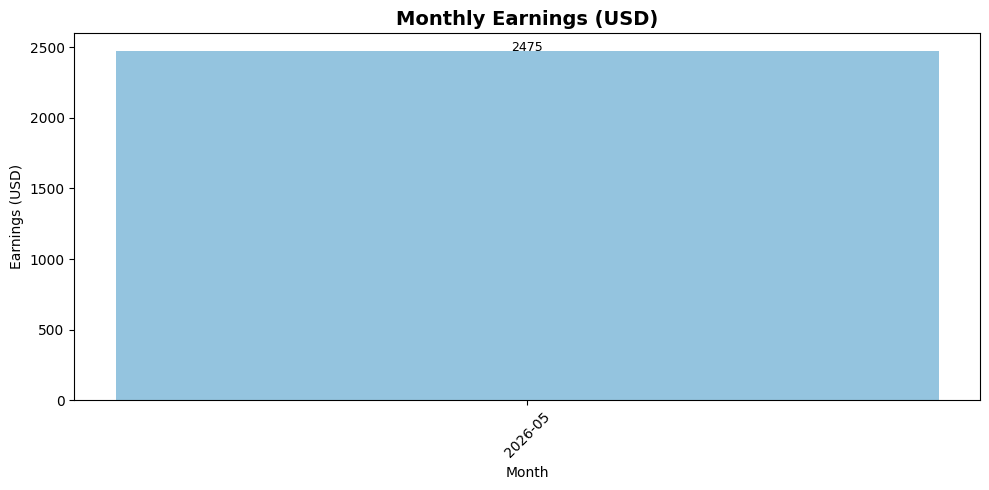

Saved: charts/monthly_earnings.png


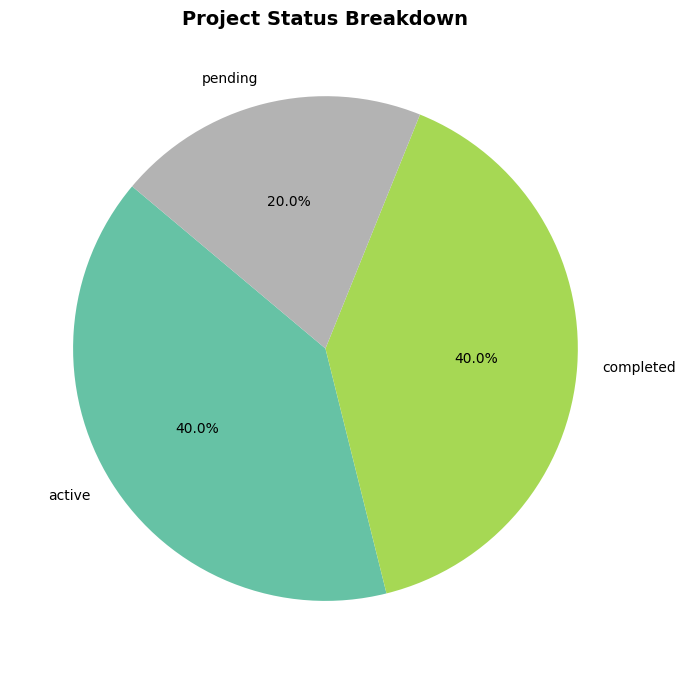

Saved: charts/project_status.png


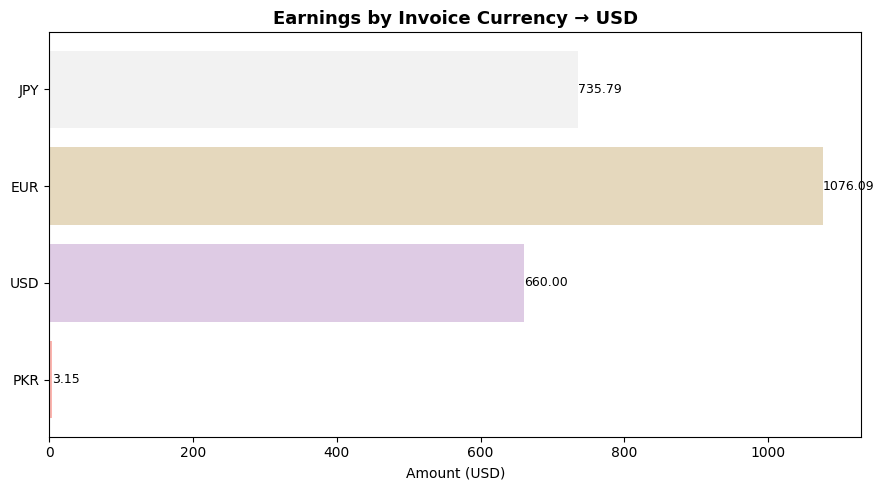

Saved: charts/earnings_by_currency.png


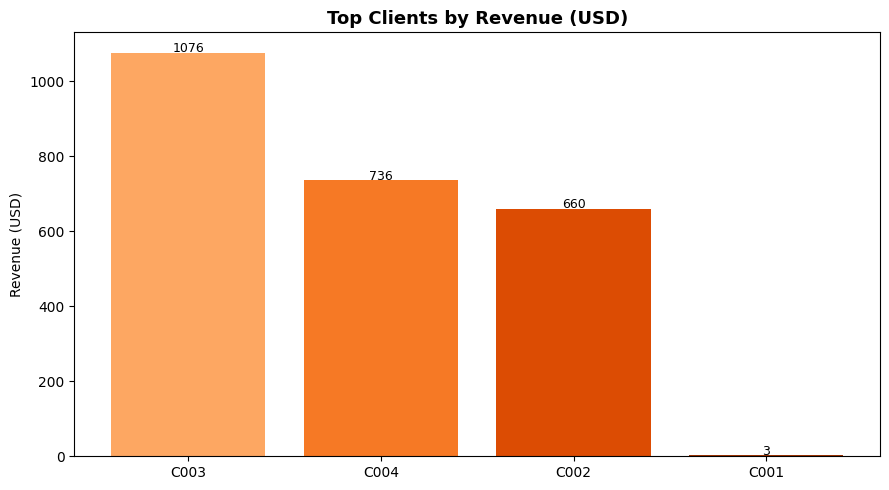

Saved: charts/top_clients.png

════════════════════════════════════════
  Exchange Rates  (Base: USD)
  Updated: backup rates (no internet)
════════════════════════════════════════
  1 USD  =      1.0000  USD
  1 USD  =      0.9200  EUR
  1 USD  =      0.7900  GBP
  1 USD  =    278.5000  PKR
  1 USD  =      3.6700  AED
  1 USD  =      1.3600  CAD
  1 USD  =      1.5300  AUD
  1 USD  =    149.5000  JPY
  1 USD  =     83.1000  INR
  1 USD  =      0.9000  CHF
════════════════════════════════════════

Launching the main menu...

Welcome to the Multi-Currency Freelance Manager!

╔══════════════════════════════════════════════╗
║     Multi-Currency Freelance Manager         ║
╠══════════════════════════════════════════════╣
║  CLIENTS            PROJECTS      TASKS      ║
║   1. Add Client      4. Add        7. Add    ║
║   2. View Clients    5. View       8. View   ║
║   3. Delete          6. Status     9. Done   ║
╠══════════════════════════════════════════════╣
║  INVOICES                

In [3]:

# --Install Required Libraries--


# these are the extra libraries we need that don't come with python by default
# fpdf2 is for making PDF files, requests is for getting data from the internet
!pip install requests fpdf2 -q


# --Import Everything We Need--


# built-in python libraries
import csv          # for reading and writing csv files
import json         # for saving data in json format
import os           # for checking if files exist
import datetime     # for getting today's date
import requests     # for fetching live exchange rates from the internet
import re           # for checking if an email address looks valid

# data science libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# for generating pdf invoices
from fpdf import FPDF


# --Currency Converter Class--


# this class handles everything related to currencies
# it fetches live rates from the internet and lets us convert between currencies
class CurrencyConverter:

    def __init__(self):
        # list of currencies our system supports
        self.supported = ["USD", "EUR", "GBP", "PKR", "AED", "CAD", "AUD", "JPY", "INR", "CHF"]
        self.rates = {}
        self.last_updated = ""

        # check if we already saved rates before so we don't fetch every time
        if os.path.exists("rates.json"):
            with open("rates.json") as f:
                saved = json.load(f)
            self.rates = saved["rates"]
            self.last_updated = saved["updated"]
            print("Loaded exchange rates from saved file (rates.json)")
        else:
            # no saved file found so go fetch from internet
            self.fetch_rates()

    def fetch_rates(self):
        # this method scrapes live exchange rates from exchangerate.host
        # it's a free api so no key is needed, just send the request and read the responses
        print("Fetching live exchange rates from the internet...")
        try:
            url = "https://api.exchangerate.host/live"
            params = {
                "source": "USD",
                "currencies": ",".join(self.supported),
                "format": 1
            }
            response = requests.get(url, params=params, timeout=10)
            data = response.json()

            if data.get("success") and data.get("quotes"):
                # the api returns keys like "USDEUR" so we strip the first 3 chars to get "EUR"
                self.rates = {}
                for key, value in data["quotes"].items():
                    currency_code = key[3:]
                    self.rates[currency_code] = value
                self.rates["USD"] = 1.0  # USD to USD is always 1

                self.last_updated = str(datetime.datetime.now())

                # save to file so we can reuse these rates next time
                with open("rates.json", "w") as f:
                    json.dump({"rates": self.rates, "updated": self.last_updated}, f)

                print("Live rates fetched and saved!")
                print("Last updated:", self.last_updated)
            else:
                # api responded but something went wrong with the data
                raise Exception("API returned an unexpected response")

        except Exception as e:
            # if internet fails or anything goes wrong, use these backup rates
            print("Could not get live rates:", e)
            print("Using backup rates instead (these are approximate)")
            self.rates = {
                "USD": 1.0,   "EUR": 0.92,  "GBP": 0.79,
                "PKR": 278.5, "AED": 3.67,  "CAD": 1.36,
                "AUD": 1.53,  "JPY": 149.5, "INR": 83.1,
                "CHF": 0.90
            }
            self.last_updated = "backup rates (no internet)"

    def refresh(self):
        # delete the saved file and fetch fresh rates from internet
        if os.path.exists("rates.json"):
            os.remove("rates.json")
        self.fetch_rates()

    def convert(self, amount, from_cur, to_cur):
        # converts an amount from one currency to another
        # the trick is we convert everything to USD first then to the target
        from_cur = from_cur.upper()
        to_cur = to_cur.upper()

        if from_cur == to_cur:
            return round(amount, 2)

        if from_cur not in self.rates or to_cur not in self.rates:
            print("Sorry, that currency is not supported")
            return amount

        # step 1: convert to USD
        in_usd = amount / self.rates[from_cur]
        # step 2: convert from USD to target
        result = in_usd * self.rates[to_cur]
        return round(result, 2)

    def get_rate(self, from_cur, to_cur):
        # just returns how much 1 unit of from_cur equals in to_cur
        return self.convert(1.0, from_cur, to_cur)

    def show_all_rates(self, base="USD"):
        print("\n" + "═"*40)
        print(f"  Exchange Rates  (Base: {base})")
        print(f"  Updated: {self.last_updated}")
        print("═"*40)
        for currency in self.supported:
            rate = self.get_rate(base, currency)
            print(f"  1 {base}  =  {rate:>10.4f}  {currency}")
        print("═"*40)


# create one global converter object that every part of the program can use
converter = CurrencyConverter()


# --All the Main Classes--



# InternationalClient: stores info about a client
class InternationalClient:

    def __init__(self, client_id, name, email, country, currency="USD"):
        self.client_id = client_id
        self.name = name
        self.email = email
        self.country = country
        self.currency = currency.upper() # always store in uppercase e.g. "USD"

    def to_dict(self):
        # turns the object into a dictionary so it can be saved to a csv file
        return {
            "client_id": self.client_id,
            "name": self.name,
            "email": self.email,
            "country": self.country,
            "currency": self.currency
        }

    def show(self):
        print(f"  [{self.client_id}]  {self.name}  |  {self.email}  |  {self.country}  |  {self.currency}")


# Project: represents one freelance project
class Project:

    def __init__(self, project_id, client_id, title, rate, currency="USD", payment_terms="Net-30", status="active"):
        self.project_id = project_id
        self.client_id = client_id
        self.title = title
        self.rate = float(rate)       # hourly or fixed rate
        self.currency = currency.upper()
        self.payment_terms = payment_terms  # e.g. Net-30 means payment due in 30 days
        self.status = status          # active, completed, pending or cancelled

    def to_dict(self):
        return {
            "project_id": self.project_id,
            "client_id": self.client_id,
            "title": self.title,
            "rate": self.rate,
            "currency": self.currency,
            "payment_terms": self.payment_terms,
            "status": self.status
        }

    def show(self):
        print(f"  [{self.project_id}]  {self.title}  |  Rate: {self.rate} {self.currency}  |  {self.status}")

# CurrencyConvertedInvoice: the main invoice class
# stores amounts in the project's currency and converts on the fly
class CurrencyConvertedInvoice:

    TAX_RATE = 0.10  # we apply a flat 10% tax to all invoices

    def __init__(self, invoice_id, project, client, items_list, invoice_currency=""):
        self.invoice_id = invoice_id
        self.project = project
        self.client = client
        # items_list is a list of dicts like: [{"desc": "logo design", "qty": 1, "price": 200}]
        self.items = items_list
        self.native_currency = project.currency   # what currency the project rates are in
        # invoice currency is what the client actually sees on the invoice
        # default to the client's preferred currency if nothing is specified
        if invoice_currency:
            self.invoice_currency = invoice_currency.upper()
        else:
            self.invoice_currency = client.currency
        self.date_issued = str(datetime.date.today())
        # add 30 days to get the due date
        self.date_due = str(datetime.date.today() + datetime.timedelta(days=30))
        self.status = "unpaid"

    def get_subtotal(self):
        # add up all the line items (qty x price for each one)
        total = 0
        for item in self.items:
            total += item["qty"] * item["price"]
        return round(total, 2)

    def get_tax(self):
        # 10% of the subtotal
        return round(self.get_subtotal() * self.TAX_RATE, 2)

    def get_total(self):
        # subtotal + tax
        return round(self.get_subtotal() + self.get_tax(), 2)

    def get_subtotal_in(self, currency):
        # convert subtotal from native project currency to any other currency
        return converter.convert(self.get_subtotal(), self.native_currency, currency)

    def get_tax_in(self, currency):
        return converter.convert(self.get_tax(), self.native_currency, currency)

    def get_total_in(self, currency):
        return converter.convert(self.get_total(), self.native_currency, currency)

    def show_invoice(self, display_currency=""):
        # if no currency is given just use the invoice's default
        if not display_currency:
            display_currency = self.invoice_currency

        rate = converter.get_rate(self.native_currency, display_currency)

        # print the invoice in a nice formatted box
        print("\n" + "╔" + "═"*53 + "╗")
        print(f"║  INVOICE  #{self.invoice_id:<42}║")
        print("╠" + "═"*53 + "╣")
        print(f"║  Client  : {self.client.name:<41}║")
        print(f"║  Country : {self.client.country:<41}║")
        print(f"║  Project : {self.project.title:<41}║")
        print(f"║  Issued  : {self.date_issued}     Due: {self.date_due:<19}║")
        print(f"║  Currency: 1 {self.native_currency} = {rate:.4f} {display_currency:<28}║")
        print(f"║  Status  : {self.status.upper():<41}║")
        print("╠" + "═"*53 + "╣")
        print(f"║  {'Description':<22} {'Qty':>5} {'Unit':>9} {'Total':>11}  ║")
        print("╠" + "─"*53 + "╣")
        for item in self.items:
            unit_c  = converter.convert(item["price"], self.native_currency, display_currency)
            total_c = converter.convert(item["qty"] * item["price"], self.native_currency, display_currency)
            desc = item["desc"][:22]
            print(f"║  {desc:<22} {item['qty']:>5.1f} {unit_c:>9.2f} {total_c:>11.2f}  ║")
        print("╠" + "═"*53 + "╣")
        print(f"║  {'Subtotal':<35} {self.get_subtotal_in(display_currency):>10.2f} {display_currency}  ║")
        print(f"║  {'Tax (10%)':<35} {self.get_tax_in(display_currency):>10.2f} {display_currency}  ║")
        print(f"║  {'TOTAL DUE':<35} {self.get_total_in(display_currency):>10.2f} {display_currency}  ║")
        print("╚" + "═"*53 + "╝")

    def to_dict(self):
        # convert to dict for saving, the items get saved as a json string inside the csv
        return {
            "invoice_id": self.invoice_id,
            "project_id": self.project.project_id,
            "client_id": self.client.client_id,
            "native_currency": self.native_currency,
            "invoice_currency": self.invoice_currency,
            "subtotal": self.get_subtotal(),
            "tax": self.get_tax(),
            "total": self.get_total(),
            "date_issued": self.date_issued,
            "date_due": self.date_due,
            "status": self.status,
            "items": json.dumps(self.items)  # turn list into string for csv storage
        }

# Task: a small unit of work logged against a project
class Task:

    def __init__(self, task_id, project_id, description, hours, done=False):
        self.task_id = task_id
        self.project_id = project_id
        self.description = description
        self.hours = float(hours)
        self.done = done
        self.created = str(datetime.date.today())

    def to_dict(self):
        return {
            "task_id": self.task_id,
            "project_id": self.project_id,
            "description": self.description,
            "hours": self.hours,
            "done": self.done,
            "created": self.created
        }

    def show(self):
        status = "✔ Done" if self.done else "Pending"
        print(f"  [{self.task_id}]  {self.description}  |  {self.hours}hrs  |  {status}  |  Project: {self.project_id}")


print("All classes defined successfully!")


# --Functions to Save and Load CSV Files--


# Clients

def save_clients(clients_list):
    # writes all clients to clients.csv, overwrites the file each time
    with open("clients.csv", "w", newline="") as f:
        fields = ["client_id", "name", "email", "country", "currency"]
        writer = csv.DictWriter(f, fieldnames=fields)
        writer.writeheader()
        for c in clients_list:
            writer.writerow(c.to_dict())

def load_clients():
    # reads clients.csv and returns a list of InternationalClient objects
    clients_list = []
    if not os.path.exists("clients.csv"):
        return clients_list
    with open("clients.csv", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            c = InternationalClient(row["client_id"], row["name"], row["email"], row["country"], row["currency"])
            clients_list.append(c)
    return clients_list


# Projects

def save_projects(projects_list):
    with open("projects.csv", "w", newline="") as f:
        fields = ["project_id", "client_id", "title", "rate", "currency", "payment_terms", "status"]
        writer = csv.DictWriter(f, fieldnames=fields)
        writer.writeheader()
        for p in projects_list:
            writer.writerow(p.to_dict())

def load_projects():
    projects_list = []
    if not os.path.exists("projects.csv"):
        return projects_list
    with open("projects.csv", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            p = Project(row["project_id"], row["client_id"], row["title"],
                        row["rate"], row["currency"], row["payment_terms"], row["status"])
            projects_list.append(p)
    return projects_list


# Invoices

# invoices are appended one by one instead of rewriting the whole file
# this is because invoice objects are hard to fully reconstruct from csv

def save_invoice_row(invoice):
    # append one invoice row to the csv file
    file_exists = os.path.exists("invoices.csv")
    fields = ["invoice_id", "project_id", "client_id", "native_currency",
              "invoice_currency", "subtotal", "tax", "total",
              "date_issued", "date_due", "status", "items"]
    with open("invoices.csv", "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fields)
        if not file_exists:
            writer.writeheader()  # only write header if file is new
        writer.writerow(invoice.to_dict())

def load_invoices_raw():
    # returns a list of plain dictionaries (not objects) from the csv
    rows = []
    if not os.path.exists("invoices.csv"):
        return rows
    with open("invoices.csv", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows.append(row)
    return rows

def update_invoice_status(invoice_id, new_status):
    # reads all invoices, changes the matching one, then saves them all back
    rows = load_invoices_raw()
    for row in rows:
        if row["invoice_id"] == invoice_id:
            row["status"] = new_status
    if rows:
        with open("invoices.csv", "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
            writer.writeheader()
            writer.writerows(rows)


# Tasks

def save_tasks(tasks_list):
    with open("tasks.csv", "w", newline="") as f:
        fields = ["task_id", "project_id", "description", "hours", "done", "created"]
        writer = csv.DictWriter(f, fieldnames=fields)
        writer.writeheader()
        for t in tasks_list:
            writer.writerow(t.to_dict())

def load_tasks():
    tasks_list = []
    if not os.path.exists("tasks.csv"):
        return tasks_list
    with open("tasks.csv", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            # "True" is stored as a string in csv so we convert it back to boolean
            t = Task(row["task_id"], row["project_id"], row["description"],
                     row["hours"], row["done"] == "True")
            tasks_list.append(t)
    return tasks_list





# --Financial Calculations--



def show_financial_summary(report_currency="USD", expenses=0):
    rows = load_invoices_raw()

    if len(rows) == 0:
        print("No invoices found yet.")
        return

    # go through each invoice and convert its total to the report currency
    gross_list = []
    tax_list   = []
    net_list   = []
    paid_list  = []

    for row in rows:
        native_total = float(row["total"])
        native_tax   = float(row["tax"])
        native_cur   = row["native_currency"]

        gross = converter.convert(native_total, native_cur, report_currency)
        tax   = converter.convert(native_tax,   native_cur, report_currency)
        net   = round(gross - tax, 2)

        gross_list.append(gross)
        tax_list.append(tax)
        net_list.append(net)

        if row["status"] == "paid":
            paid_list.append(gross)

    # use numpy to sum the lists
    total_gross = float(np.sum(gross_list))
    total_tax   = float(np.sum(tax_list))
    total_net   = float(np.sum(net_list))
    total_paid  = float(np.sum(paid_list)) if paid_list else 0.0

    # profit margin formula: (gross - expenses) / gross * 100
    if total_gross > 0:
        profit_margin = round((total_gross - expenses) / total_gross * 100, 2)
    else:
        profit_margin = 0.0

    # print the summary in a box like the invoice
    print("\n" + "╔" + "═"*48 + "╗")
    print(f"║  FINANCIAL SUMMARY  (in {report_currency}){'':>21}║")
    print("╠" + "═"*48 + "╣")
    print(f"║  Total Gross Earnings  : {total_gross:>12.2f} {report_currency}    ║")
    print(f"║  Total Tax Collected   : {total_tax:>12.2f} {report_currency}    ║")
    print(f"║  Total Net Income      : {total_net:>12.2f} {report_currency}    ║")
    print(f"║  Paid Invoices Total   : {total_paid:>12.2f} {report_currency}    ║")
    print(f"║  Expenses              : {expenses:>12.2f} {report_currency}    ║")
    print(f"║  Profit Margin         : {profit_margin:>11.2f} %       ║")
    print(f"║  Total Invoices        : {len(rows):>12}          ║")
    print("╚" + "═"*48 + "╝")

    # also show a full breakdown using pandas dataframe
    df_rows = []
    for row in rows:
        gross = converter.convert(float(row["total"]), row["native_currency"], report_currency)
        df_rows.append({
            "Invoice":  row["invoice_id"],
            "Client":   row["client_id"],
            "Gross":    round(gross, 2),
            "Currency": report_currency,
            "Status":   row["status"]
        })
    df = pd.DataFrame(df_rows)
    print("\nFull Invoice Breakdown:")
    print(df.to_string(index=False))



# --Charts--



# make sure the charts folder exists before trying to save to it
os.makedirs("charts", exist_ok=True)

def chart_monthly_earnings(report_currency="USD"):
    rows = load_invoices_raw()
    if not rows:
        print("No invoice data to chart yet.")
        return

    # group earnings by month using a plain dictionary
    monthly = {}
    for row in rows:
        month = row["date_issued"][:7]  # "2024-05-15" becomes "2024-05"
        gross = converter.convert(float(row["total"]), row["native_currency"], report_currency)
        if month in monthly:
            monthly[month] += gross
        else:
            monthly[month] = gross

    months   = sorted(monthly.keys())
    earnings = [monthly[m] for m in months]

    # use numpy linspace to spread colours evenly across the colormap
    colours = plt.cm.Blues(np.linspace(0.4, 0.9, len(months)))

    plt.figure(figsize=(10, 5))
    bars = plt.bar(months, earnings, color=colours)
    plt.title(f"Monthly Earnings ({report_currency})", fontsize=14, fontweight="bold")
    plt.xlabel("Month")
    plt.ylabel(f"Earnings ({report_currency})")
    plt.xticks(rotation=45)
    # put value labels on top of each bar
    for bar, val in zip(bars, earnings):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{val:.0f}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("charts/monthly_earnings.png", dpi=150)
    plt.show()
    print("Saved: charts/monthly_earnings.png")


def chart_project_status():
    projects = load_projects()
    if not projects:
        print("No projects to chart.")
        return

    # count how many projects are in each status
    status_count = {}
    for p in projects:
        if p.status in status_count:
            status_count[p.status] += 1
        else:
            status_count[p.status] = 1

    labels  = list(status_count.keys())
    sizes   = list(status_count.values())
    colours = plt.cm.Set2(np.linspace(0, 1, len(labels)))

    plt.figure(figsize=(7, 7))
    plt.pie(sizes, labels=labels, autopct="%1.1f%%", colors=colours, startangle=140)
    plt.title("Project Status Breakdown", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("charts/project_status.png", dpi=150)
    plt.show()
    print("Saved: charts/project_status.png")


def chart_earnings_by_currency(report_currency="USD"):
    rows = load_invoices_raw()
    if not rows:
        print("No data to chart.")
        return

    # group earnings by which currency the invoice was in
    by_currency = {}
    for row in rows:
        cur   = row["invoice_currency"]
        gross = converter.convert(float(row["total"]), row["native_currency"], report_currency)
        if cur in by_currency:
            by_currency[cur] += gross
        else:
            by_currency[cur] = gross

    currencies = list(by_currency.keys())
    amounts    = [by_currency[c] for c in currencies]
    colours    = plt.cm.Pastel1(np.linspace(0, 1, len(currencies)))

    plt.figure(figsize=(9, 5))
    bars = plt.barh(currencies, amounts, color=colours)
    plt.title(f"Earnings by Invoice Currency → {report_currency}", fontsize=13, fontweight="bold")
    plt.xlabel(f"Amount ({report_currency})")
    for bar, val in zip(bars, amounts):
        plt.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f"{val:.2f}", va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("charts/earnings_by_currency.png", dpi=150)
    plt.show()
    print("Saved: charts/earnings_by_currency.png")


def chart_top_clients(report_currency="USD"):
    rows = load_invoices_raw()
    if not rows:
        print("No data to chart.")
        return

    # add up earnings per client
    client_earnings = {}
    for row in rows:
        cid   = row["client_id"]
        gross = converter.convert(float(row["total"]), row["native_currency"], report_currency)
        if cid in client_earnings:
            client_earnings[cid] += gross
        else:
            client_earnings[cid] = gross

    # sort by earnings descending and take top 5
    sorted_clients = sorted(client_earnings.items(), key=lambda x: x[1], reverse=True)[:5]
    names   = [item[0] for item in sorted_clients]
    values  = [item[1] for item in sorted_clients]
    colours = plt.cm.Oranges(np.linspace(0.4, 0.9, len(names)))

    plt.figure(figsize=(9, 5))
    bars = plt.bar(names, values, color=colours)
    plt.title(f"Top Clients by Revenue ({report_currency})", fontsize=13, fontweight="bold")
    plt.ylabel(f"Revenue ({report_currency})")
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{val:.0f}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("charts/top_clients.png", dpi=150)
    plt.show()
    print("Saved: charts/top_clients.png")



# --PDF Invoice Generator--



def generate_pdf_invoice(invoice, display_currency=""):
    # if no currency given just use the invoice default
    if not display_currency:
        display_currency = invoice.invoice_currency

    rate = converter.get_rate(invoice.native_currency, display_currency)

    pdf = FPDF()
    pdf.add_page()

    # blue header bar across the top of the page
    pdf.set_fill_color(30, 80, 162)
    pdf.rect(0, 0, 210, 30, "F")
    pdf.set_font("Helvetica", "B", 20)
    pdf.set_text_color(255, 255, 255)
    pdf.cell(0, 20, "FREELANCE INVOICE", align="C", new_x="LMARGIN", new_y="NEXT")
    pdf.set_font("Helvetica", "", 10)
    pdf.cell(0, 10, "Multi-Currency Freelance Management System", align="C", new_x="LMARGIN", new_y="NEXT")

    # back to black text for the rest
    pdf.set_text_color(0, 0, 0)
    pdf.ln(5)

    # invoice info block
    pdf.set_font("Helvetica", "B", 11)
    pdf.cell(0, 8, f"Invoice #: {invoice.invoice_id}     Status: {invoice.status.upper()}", new_x="LMARGIN", new_y="NEXT")
    pdf.set_font("Helvetica", "", 10)
    pdf.cell(0, 7, f"Date Issued : {invoice.date_issued}     Due Date: {invoice.date_due}", new_x="LMARGIN", new_y="NEXT")
    pdf.cell(0, 7, f"Client      : {invoice.client.name}  |  {invoice.client.email}  |  {invoice.client.country}", new_x="LMARGIN", new_y="NEXT")
    pdf.cell(0, 7, f"Project     : {invoice.project.title}     Terms: {invoice.project.payment_terms}", new_x="LMARGIN", new_y="NEXT")
    pdf.cell(0, 7, f"Rate        : 1 {invoice.native_currency} = {rate:.4f} {display_currency}", new_x="LMARGIN", new_y="NEXT")
    pdf.ln(4)

    # blue table header row
    pdf.set_fill_color(30, 80, 162)
    pdf.set_text_color(255, 255, 255)
    pdf.set_font("Helvetica", "B", 10)
    pdf.cell(90, 8, "Description", fill=True)
    pdf.cell(25, 8, "Qty",                  fill=True, align="C")
    pdf.cell(35, 8, f"Unit ({display_currency})",  fill=True, align="R")
    pdf.cell(40, 8, f"Total ({display_currency})", fill=True, align="R")
    pdf.ln()

    # table rows with alternating background colours
    pdf.set_text_color(0, 0, 0)
    pdf.set_font("Helvetica", "", 10)
    shade = False
    for item in invoice.items:
        if shade:
            pdf.set_fill_color(225, 235, 255)
        else:
            pdf.set_fill_color(255, 255, 255)
        unit_c  = converter.convert(item["price"],                  invoice.native_currency, display_currency)
        total_c = converter.convert(item["qty"] * item["price"],    invoice.native_currency, display_currency)
        pdf.cell(90, 7, item["desc"][:42], fill=True)
        pdf.cell(25, 7, str(item["qty"]),   fill=True, align="C")
        pdf.cell(35, 7, f"{unit_c:.2f}",    fill=True, align="R")
        pdf.cell(40, 7, f"{total_c:.2f}",   fill=True, align="R")
        pdf.ln()
        shade = not shade  # flip for next row

    pdf.ln(3)

    # totals section
    pdf.set_font("Helvetica", "", 10)
    pdf.cell(150, 7, "Subtotal", align="R")
    pdf.cell(40,  7, f"{invoice.get_subtotal_in(display_currency):.2f} {display_currency}", align="R")
    pdf.ln()
    pdf.cell(150, 7, "Tax (10%)", align="R")
    pdf.cell(40,  7, f"{invoice.get_tax_in(display_currency):.2f} {display_currency}", align="R")
    pdf.ln()

    # total due in blue bar at the bottom
    pdf.set_fill_color(30, 80, 162)
    pdf.set_text_color(255, 255, 255)
    pdf.set_font("Helvetica", "B", 12)
    pdf.cell(150, 9, "TOTAL DUE", align="R", fill=True)
    pdf.cell(40,  9, f"{invoice.get_total_in(display_currency):.2f} {display_currency}", align="R", fill=True)

    filename = f"invoice_{invoice.invoice_id}_{display_currency}.pdf"
    pdf.output(filename)
    print(f"PDF invoice saved as: {filename}")
    return filename



# --Input Validation and Helper Functions--



# list of currencies the system knows about
SUPPORTED_CURRENCIES = ["USD", "EUR", "GBP", "PKR", "AED", "CAD", "AUD", "JPY", "INR", "CHF"]

def is_valid_email(email):
    # checks if the email has a basic valid format using regex
    # e.g. someone@example.com would pass
    return bool(re.match(r"[^@]+@[^@]+\.[^@]+", email))

def is_valid_currency(currency):
    return currency.upper() in SUPPORTED_CURRENCIES

def get_input(prompt, expected_type=str, allow_empty=False, default=None):
    # keeps asking the user until they give a valid input
    # expected_type can be str, float, int etc
    while True:
        try:
            user_input = input(prompt).strip()

            # if they just pressed enter and we have a default, use it
            if user_input == "" and default is not None:
                return default

            # if empty is allowed return empty string
            if user_input == "" and allow_empty:
                return ""

            # try to convert to the expected type (e.g. float("abc") would fail)
            value = expected_type(user_input)
            return value

        except ValueError:
            print(f"  ❌ Invalid input. Please enter a {expected_type.__name__}.")
        except EOFError:
            # this can happen in colab sometimes, just return the default
            if default is not None:
                return default
            return expected_type()



# --FreelanceManager (Main Controller Class)--



class FreelanceManager:

    def __init__(self):
        # load all existing data from csv files when the program starts
        self.clients  = load_clients()
        self.projects = load_projects()
        self.tasks    = load_tasks()

        # set up ID counters so new records get unique IDs
        # start from len+1 so we don't repeat existing IDs
        self.client_count  = len(self.clients)  + 1
        self.project_count = len(self.projects) + 1
        self.task_count    = len(self.tasks)    + 1
        self.invoice_count = len(load_invoices_raw()) + 1

    # these four methods just generate the next available ID
    def new_client_id(self):
        cid = f"C{self.client_count:03d}"
        self.client_count += 1
        return cid

    def new_project_id(self):
        pid = f"P{self.project_count:03d}"
        self.project_count += 1
        return pid

    def new_task_id(self):
        tid = f"T{self.task_count:03d}"
        self.task_count += 1
        return tid

    def new_invoice_id(self):
        iid = f"INV{self.invoice_count:04d}"
        self.invoice_count += 1
        return iid

    def find_client(self, client_id):
        # loop through clients and return the one with matching id
        for c in self.clients:
            if c.client_id == client_id:
                return c
        return None  # return None if not found

    def find_project(self, project_id):
        for p in self.projects:
            if p.project_id == project_id:
                return p
        return None

    # CLIENT FUNCTIONS

    def add_client(self):
        print("\n╔══════════════════════════╗")
        print("║      Add New Client      ║")
        print("╚══════════════════════════╝")

        name = get_input("  Name    : ")

        # keep asking until the email format is valid
        while True:
            email = get_input("  Email   : ")
            if is_valid_email(email):
                break
            print("  ❌ Email doesn't look right. Try again.")

        country = get_input("  Country : ")

        # keep asking until the currency is one we support
        while True:
            currency = get_input(f"  Currency {SUPPORTED_CURRENCIES[:5]}... : ").upper()
            if is_valid_currency(currency):
                break
            print("  ❌ Currency not supported. Try again.")

        new_client = InternationalClient(self.new_client_id(), name, email, country, currency)
        self.clients.append(new_client)
        save_clients(self.clients)
        print(f"\n  ✅ Client added! ID: {new_client.client_id}")

    def list_clients(self):
        if not self.clients:
            print("  No clients added yet.")
            return
        print("\n╔══════════════════════════╗")
        print("║        All Clients       ║")
        print("╚══════════════════════════╝")
        for c in self.clients:
            c.show()

    def delete_client(self):
        self.list_clients()
        cid = get_input("  Client ID to delete: ")
        self.clients = [c for c in self.clients if c.client_id != cid]
        save_clients(self.clients)
        print("  ✅ Client deleted.")

    # PROJECT FUNCTIONS

    def add_project(self):
        print("\n╔══════════════════════════╗")
        print("║      Add New Project     ║")
        print("╚══════════════════════════╝")
        self.list_clients()

        cid = get_input("  Client ID : ")
        if not self.find_client(cid):
            print("  ❌ Client not found!")
            return

        title = get_input("  Title     : ")
        rate  = get_input("  Rate      : ", float)

        while True:
            currency = get_input("  Currency  : ").upper()
            if is_valid_currency(currency):
                break
            print("  ❌ Not supported. Try again.")

        terms = get_input("  Pay Terms [Net-30]: ", default="Net-30")

        new_project = Project(self.new_project_id(), cid, title, rate, currency, terms)
        self.projects.append(new_project)
        save_projects(self.projects)
        print(f"\n  ✅ Project added! ID: {new_project.project_id}")

    def list_projects(self):
        if not self.projects:
            print("  No projects added yet.")
            return
        print("\n╔══════════════════════════╗")
        print("║       All Projects       ║")
        print("╚══════════════════════════╝")
        for p in self.projects:
            p.show()

    def update_status(self):
        self.list_projects()
        pid = get_input("  Project ID : ")
        p   = self.find_project(pid)
        if not p:
            print("  ❌ Project not found!")
            return
        print("  Options: active / completed / pending / cancelled")
        new_status = get_input("  New Status : ")
        if new_status not in ["active", "completed", "pending", "cancelled"]:
            print("  ❌ Invalid status.")
            return
        p.status = new_status
        save_projects(self.projects)
        print("  ✅ Status updated!")

    def delete_project(self):
        self.list_projects()
        pid = get_input("  Project ID to delete: ")
        self.projects = [p for p in self.projects if p.project_id != pid]
        save_projects(self.projects)
        print("  ✅ Project deleted.")

    # TASK FUNCTIONS

    def add_task(self):
        print("\n╔══════════════════════════╗")
        print("║        Add Task          ║")
        print("╚══════════════════════════╝")
        self.list_projects()

        pid   = get_input("  Project ID  : ")
        desc  = get_input("  Description : ")
        hours = get_input("  Hours spent : ", float)

        new_task = Task(self.new_task_id(), pid, desc, hours)
        self.tasks.append(new_task)
        save_tasks(self.tasks)
        print(f"  ✅ Task added! ID: {new_task.task_id}")

    def list_tasks(self):
        if not self.tasks:
            print("  No tasks added yet.")
            return
        print("\n╔══════════════════════════╗")
        print("║         All Tasks        ║")
        print("╚══════════════════════════╝")
        for t in self.tasks:
            t.show()

    def complete_task(self):
        self.list_tasks()
        tid = get_input("  Task ID to mark done: ")
        for t in self.tasks:
            if t.task_id == tid:
                t.done = True
                save_tasks(self.tasks)
                print("  ✅ Task marked as done!")
                return
        print("  ❌ Task not found.")

    # INVOICE FUNCTIONS

    def create_invoice(self):
        print("\n╔══════════════════════════╗")
        print("║      Create Invoice      ║")
        print("╚══════════════════════════╝")
        self.list_projects()

        pid     = get_input("  Project ID : ")
        project = self.find_project(pid)
        if not project:
            print("  ❌ Project not found!")
            return

        client = self.find_client(project.client_id)
        if not client:
            print("  ❌ Client not found!")
            return

        # collect line items one by one
        items = []
        print("\n  Add items to the invoice.")
        print("  Leave description blank and press enter to stop.\n")
        while True:
            desc = get_input("  Description : ", allow_empty=True)
            if desc == "":
                break
            qty   = get_input("  Quantity    : ", float)
            price = get_input(f"  Unit Price ({project.currency}) : ", float)
            items.append({"desc": desc, "qty": qty, "price": price})

        if not items:
            print("  No items added. Invoice cancelled.")
            return

        # ask which currency to show on the invoice
        print(f"\n  Client's preferred currency is: {client.currency}")
        inv_cur = get_input(f"  Invoice currency [{client.currency}]: ", default=client.currency).upper()
        if not is_valid_currency(inv_cur):
            print("  Invalid currency, using client default.")
            inv_cur = client.currency

        invoice = CurrencyConvertedInvoice(self.new_invoice_id(), project, client, items, inv_cur)
        invoice.show_invoice(inv_cur)
        save_invoice_row(invoice)

        # offer to generate a pdf
        make_pdf = get_input("\n  Generate PDF invoice? (y/n) [y]: ", default="y")
        if make_pdf.lower() == "y":
            generate_pdf_invoice(invoice, inv_cur)

    def view_invoices(self):
        rows = load_invoices_raw()
        if not rows:
            print("  No invoices yet.")
            return
        print("\n╔══════════════════════════╗")
        print("║       All Invoices       ║")
        print("╚══════════════════════════╝")
        # show invoices in a pandas dataframe for a clean table view
        df = pd.DataFrame(rows)[["invoice_id", "client_id", "project_id",
                                  "total", "native_currency", "invoice_currency",
                                  "date_issued", "status"]]
        print(df.to_string(index=False))

    def mark_paid(self):
        self.view_invoices()
        iid = get_input("  Invoice ID to mark as paid: ")
        update_invoice_status(iid, "paid")
        print("  ✅ Invoice marked as paid!")

    # CURRENCY TOOLS

    def currency_tools(self):
        print("\n╔══════════════════════════╗")
        print("║      Currency Tools      ║")
        print("╠══════════════════════════╣")
        print("║  1. Show all rates       ║")
        print("║  2. Convert an amount    ║")
        print("║  3. Refresh live rates   ║")
        print("╚══════════════════════════╝")
        choice = get_input("  Choice: ")

        if choice == "1":
            base = get_input("  Base currency [USD]: ", default="USD").upper()
            converter.show_all_rates(base)

        elif choice == "2":
            amount   = get_input("  Amount        : ", float)
            from_cur = get_input("  From currency : ").upper()
            to_cur   = get_input("  To currency   : ").upper()
            result   = converter.convert(amount, from_cur, to_cur)
            print(f"\n  {amount} {from_cur}  =  {result} {to_cur}")

        elif choice == "3":
            converter.refresh()
            print("  ✅ Rates refreshed!")

    # REPORTS AND CHARTS

    def reports(self):
        print("\n╔══════════════════════════╗")
        print("║    Reports and Charts    ║")
        print("╚══════════════════════════╝")

        currency = get_input("  Report currency [USD]: ", default="USD").upper()
        expenses = get_input("  Your total expenses [0]: ", float, default=0.0)

        show_financial_summary(currency, expenses)

        print("\n  Generating all charts now...")
        chart_monthly_earnings(currency)
        chart_project_status()
        chart_earnings_by_currency(currency)
        chart_top_clients(currency)
        print("\n  All 4 charts saved in the charts/ folder!")

    # MAIN MENU

    def run(self):
        print("\nWelcome to the Multi-Currency Freelance Manager!")

        while True:
            # the main menu displayed in a box
            print("""
╔══════════════════════════════════════════════╗
║     Multi-Currency Freelance Manager         ║
╠══════════════════════════════════════════════╣
║  CLIENTS            PROJECTS      TASKS      ║
║   1. Add Client      4. Add        7. Add    ║
║   2. View Clients    5. View       8. View   ║
║   3. Delete          6. Status     9. Done   ║
╠══════════════════════════════════════════════╣
║  INVOICES                                    ║
║   10. Create Invoice                         ║
║   11. View All Invoices                      ║
║   12. Mark Invoice as Paid                   ║
╠══════════════════════════════════════════════╣
║  OTHER                                       ║
║   13. Currency Tools    14. Reports & Charts ║
║   15. Delete Project    16. Refresh Rates    ║
║    0. Exit                                   ║
╚══════════════════════════════════════════════╝""")

            choice = get_input("  Enter choice: ")

            if   choice == "1":  self.add_client()
            elif choice == "2":  self.list_clients()
            elif choice == "3":  self.delete_client()
            elif choice == "4":  self.add_project()
            elif choice == "5":  self.list_projects()
            elif choice == "6":  self.update_status()
            elif choice == "7":  self.add_task()
            elif choice == "8":  self.list_tasks()
            elif choice == "9":  self.complete_task()
            elif choice == "10": self.create_invoice()
            elif choice == "11": self.view_invoices()
            elif choice == "12": self.mark_paid()
            elif choice == "13": self.currency_tools()
            elif choice == "14": self.reports()
            elif choice == "15": self.delete_project()
            elif choice == "16": converter.refresh()
            elif choice == "0":
                print("\n  Goodbye! Thanks for using Freelance Manager.")
                break
            else:
                print("  ❌ Invalid choice. Please try again.")



#  --Add Sample Data and Run the Program--



def add_sample_data():
    # only runs if no data exists yet, so it won't overwrite real data
    if os.path.exists("clients.csv"):
        print("Data files already exist. Skipping sample data.")
        return

    print("Setting up sample data for demonstration...")

    # four sample clients from different countries with different currencies
    clients = [
        InternationalClient("C001", "Ahmed Raza",    "ahmed@gmail.com",   "Pakistan", "PKR"),
        InternationalClient("C002", "Emily Clark",   "emily@outlook.com", "USA",      "USD"),
        InternationalClient("C003", "Hans Mueller",  "hans@email.de",     "Germany",  "EUR"),
        InternationalClient("C004", "Yuki Sato",     "yuki@jp.com",       "Japan",    "JPY"),
    ]
    save_clients(clients)

    # five sample projects linked to the clients above
    projects = [
        Project("P001", "C001", "E-Commerce Website",       25.0,   "PKR", "Net-30", "active"),
        Project("P002", "C002", "Data Analysis Dashboard",  75.0,   "USD", "Net-15", "completed"),
        Project("P003", "C003", "Mobile App Backend",       60.0,   "EUR", "Net-30", "active"),
        Project("P004", "C004", "AI Chatbot",               5000.0, "JPY", "Net-45", "pending"),
        Project("P005", "C001", "SEO Optimization",         20.0,   "PKR", "Net-30", "completed"),
    ]
    save_projects(projects)

    # four sample tasks across different projects
    tasks = [
        Task("T001", "P001", "Design homepage layout",  5.0,  False),
        Task("T002", "P001", "Build product pages",     8.0,  True),
        Task("T003", "P002", "Clean and prep dataset",  3.0,  True),
        Task("T004", "P003", "Set up Django server",    6.0,  False),
    ]
    save_tasks(tasks)

    # five sample invoices in different currencies
    invoice_data = [
        ("P001", "C001", "PKR", [{"desc": "Homepage Design", "qty": 10, "price": 25},
                                  {"desc": "Testing",         "qty": 2,  "price": 25}]),
        ("P002", "C002", "USD", [{"desc": "Data Cleaning",   "qty": 5,  "price": 75},
                                  {"desc": "Chart Building",  "qty": 3,  "price": 75}]),
        ("P003", "C003", "EUR", [{"desc": "API Development",  "qty": 15, "price": 60}]),
        ("P004", "C004", "JPY", [{"desc": "Chatbot Training", "qty": 20, "price": 5000}]),
        ("P005", "C001", "PKR", [{"desc": "SEO Audit Report", "qty": 1,  "price": 500}]),
    ]

    all_clients  = load_clients()
    all_projects = load_projects()

    inv_num = 1
    for pid, cid, cur, items in invoice_data:
        # find the matching project and client objects
        project = next((p for p in all_projects if p.project_id == pid), None)
        client  = next((c for c in all_clients  if c.client_id  == cid), None)

        inv = CurrencyConvertedInvoice(f"INV{inv_num:04d}", project, client, items, cur)

        # mark the first two invoices as paid so the financial report looks interesting
        if inv_num in [1, 2]:
            inv.status = "paid"

        save_invoice_row(inv)
        inv_num += 1

    print("Sample data added successfully!")


# run everything

add_sample_data()

print("\n" + "─"*50)
print("  Starting up...")
print("─"*50)

# show a financial summary right away
show_financial_summary("USD")

# generate all 4 charts automatically on startup
print("\nGenerating startup charts...")
chart_monthly_earnings("USD")
chart_project_status()
chart_earnings_by_currency("USD")
chart_top_clients("USD")

# show current exchange rates
converter.show_all_rates("USD")

# finally launch the interactive menu
print("\nLaunching the main menu...")
app = FreelanceManager()
app.run()